In [302]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString
from shapely.geometry import box


TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"
MILES_TO_METERS = 1609.344

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [303]:
EFFECTIVE_SPEEDS_MPH = {
    "I": 80,
    "U": 60,
    "S": 40,
}

def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

In [304]:
AtomicRoads = gpd.read_file("./maps/raw/IL/AtomicCenterlines_ILPrimaryRoads.geojson").to_crs(TARGET_CRS)
ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)

# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

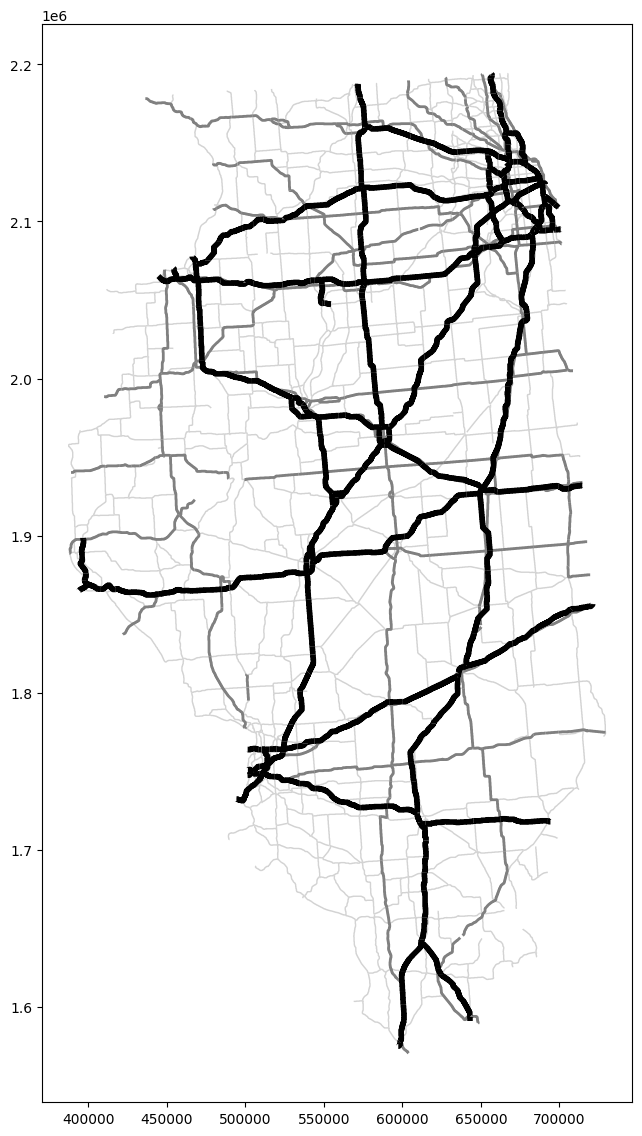

In [305]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14, 14)
)

# Original multilane roads
AtomicRoads[(
    (AtomicRoads['origin'] == 'I')
)].plot(
    ax=ax,
    color="black",
    linewidth=4,
    zorder=3
)

# Raster-derived centerlines
AtomicRoads[(
    (AtomicRoads['origin'] == 'U')
)].plot(
    ax=ax,
    color="grey",
    linewidth=2,
    zorder=2
)

AtomicRoads[(
    (AtomicRoads['origin'] == 'S')
)].plot(
    ax=ax,
    color="lightgrey",
    linewidth=1,
    zorder=1
)

plt.show()

In [306]:
from shapely.ops import nearest_points

# --------------------------------------------------
# 1. PREPARE DATA
# --------------------------------------------------

places = (
    ILPlaces2022WithChicagoCommunity_AndCensus
    .copy()
)

# Keep the road GeoDataFrame separately
roads = AtomicRoads.copy()

# Union all interstate road geometries into one
# Shapely geometry
road_system = roads.geometry.union_all()

print(
    "Road system type:",
    road_system.geom_type
)

# --------------------------------------------------
# 2. SNAP PLACE REPRESENTATIVE POINTS
# --------------------------------------------------

places["representative_point"] = (
    places.geometry.representative_point()
)

# 10 miles converted to meters
MAX_SNAP_DISTANCE_M = (
    10 * MILES_TO_METERS
)


def snap_place_to_road(
    place_polygon,
):

    nearest_place_point, nearest_road_point = (
        nearest_points(
            place_polygon,
            road_system,
        )
    )

    snap_distance_m = (
        nearest_place_point.distance(
            nearest_road_point
        )
    )

    if (
        snap_distance_m
        <= MAX_SNAP_DISTANCE_M
    ):

        return (
            nearest_road_point,
            snap_distance_m,
        )

    return (
        None,
        snap_distance_m,
    )

snap_results = (
    places["representative_point"]
    .apply(
        snap_place_to_road
    )
)

places["road_point"] = (
    snap_results.apply(
        lambda result: result[0]
    )
)

places["snap_distance_m"] = (
    snap_results.apply(
        lambda result: result[1]
    )
)

places["snap_distance_miles"] = (
    places["snap_distance_m"]
    / 1609.344
)

# --------------------------------------------------
# 3. CREATE POINT GEODATAFRAMES
# --------------------------------------------------

# Places that did not find an interstate within 10 miles
unsnapped_places = (
    places[
        places["road_point"].isna()
    ]
    .copy()
)

# Display unsnapped places using their representative point
unsnapped_places = (
    unsnapped_places
    .set_geometry(
        "representative_point"
    )
)

# Places that successfully snapped to an interstate
place_road_points = (
    places[
        places["road_point"].notna()
    ]
    .copy()
    .set_geometry(
        "road_point"
    )
)

print(
    "Total places:",
    f"{len(places):,}"
)

print(
    "Successfully snapped:",
    f"{len(place_road_points):,}"
)

print(
    "Could not snap within 10 miles:",
    f"{len(unsnapped_places):,}"
)

print(
    places[
        "snap_distance_miles"
    ].describe()
)

Road system type: MultiLineString
Total places: 897
Successfully snapped: 897
Could not snap within 10 miles: 0
count    897.000000
mean       1.089107
std        1.162932
min        0.000451
25%        0.282473
50%        0.675053
75%        1.485129
max        7.506830
Name: snap_distance_miles, dtype: float64


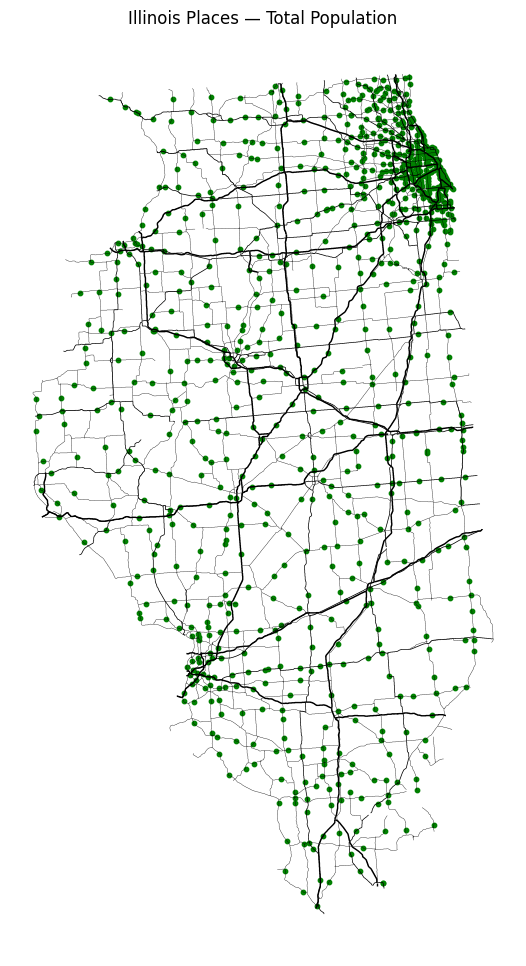

In [307]:
fig, ax = plt.subplots(figsize=(12,12))

# edges
AtomicRoads[(
    (AtomicRoads['origin'] == 'I')
)].plot(
    ax=ax,
    linewidth=1,
    color="black",
    zorder=4
)

# edges
AtomicRoads[(
    (AtomicRoads['origin'] == 'U')
)].plot(
    ax=ax,
    linewidth=0.5,
    color="black",
    zorder=3
)

# edges
AtomicRoads[(
    (AtomicRoads['origin'] == 'S')
)].plot(
    ax=ax,
    linewidth=0.25,
    color="black",
    zorder=2
)

place_road_points.plot(
    ax=ax,
    markersize=10,
    color="green"
)



ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")
# ZoomToTheExtentOf(ax, ILCollarCountiesArea)

plt.show()

In [308]:
tolerance = 1  # feet EPSG:3435

buffered_roads = AtomicRoads.copy()
buffered_roads["geometry"] = buffered_roads.geometry.buffer(tolerance)

check = gpd.sjoin(
    place_road_points[["road_point"]],
    buffered_roads[["geometry"]],
    predicate="within",
    how="left"
)

print(
    f"{check.index_right.notna().mean()*100:.2f}% within {tolerance} feet"
)

100.00% within 1 feet


C:\Users\Wayne\AppData\Local\Temp\ipykernel_40124\751161268.py:6: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  check = gpd.sjoin(


In [309]:
from shapely.geometry import Point

vertices = []

for geom in AtomicRoads.geometry:
    coords = list(geom.coords)

    vertices.append(Point(coords[0]))
    vertices.append(Point(coords[-1]))

road_vertices = gpd.GeoDataFrame(
    geometry=vertices,
    crs=AtomicRoads.crs
)

road_vertices = road_vertices.drop_duplicates()

In [310]:
vertex_check = gpd.sjoin_nearest(
    place_road_points[["road_point"]],
    road_vertices,
    how="left",
    distance_col="vertex_distance"
)

print(vertex_check.vertex_distance.describe())

count      897.000000
mean      4041.945840
std       3521.543240
min          0.000000
25%       1410.944814
50%       2960.019087
75%       5959.570393
max      18899.366799
Name: vertex_distance, dtype: float64


C:\Users\Wayne\AppData\Local\Temp\ipykernel_40124\1390772888.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  vertex_check = gpd.sjoin_nearest(


In [311]:
nearest = gpd.sjoin_nearest(
    place_road_points[["road_point"]],
    AtomicRoads[["geometry"]],
    how="left",
    distance_col="road_distance"
)

print(nearest["road_distance"].describe())

count    9.010000e+02
mean     6.214710e-12
std      2.466310e-11
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.814389e-10
Name: road_distance, dtype: float64


C:\Users\Wayne\AppData\Local\Temp\ipykernel_40124\3891921361.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  nearest = gpd.sjoin_nearest(


In [312]:
import geopandas as gpd
import pandas as pd
import networkx as nx

from shapely.geometry import Point, LineString
from shapely.ops import split, snap


# --------------------------------------------------
# SPLIT ROADS AT PLACE POINTS
# --------------------------------------------------

roads_split = []

# tolerance for snapping to line (feet)
snap_tolerance = 1


for idx, road in AtomicRoads.iterrows():

    line = road.geometry

    # places close to this road
    nearby_places = place_road_points[
        place_road_points.geometry.distance(line)
        <= snap_tolerance
    ]

    split_geom = line

    # split at each place point
    for point in nearby_places.geometry:

        split_geom = snap(
            split_geom,
            point,
            snap_tolerance
        )

        try:
            split_geom = split(
                split_geom,
                point
            )
        except:
            pass


    # save pieces
    if split_geom.geom_type == "GeometryCollection":

        for piece in split_geom.geoms:
            if piece.geom_type == "LineString":
                row = road.copy()
                row.geometry = piece
                roads_split.append(row)

    elif split_geom.geom_type == "MultiLineString":

        for piece in split_geom.geoms:
            row = road.copy()
            row.geometry = piece
            roads_split.append(row)

    else:
        row = road.copy()
        row.geometry = split_geom
        roads_split.append(row)



AtomicRoadsSplit = gpd.GeoDataFrame(
    roads_split,
    crs=AtomicRoads.crs
)


print(
    len(AtomicRoads),
    "original edges"
)

print(
    len(AtomicRoadsSplit),
    "split edges"
)

6172 original edges
6847 split edges


In [313]:
speed_map = {
    "I": 70,
    "U": 50,
    "S": 30
}

AtomicRoadsSplit["speed_mph"] = (
    AtomicRoadsSplit["origin"]
    .map(speed_map)
)

In [332]:
AtomicRoadsSplit["travel_time_hours"] = (
    AtomicRoadsSplit["length_miles"]
    / AtomicRoadsSplit["speed_mph"]
)

In [334]:
import networkx as nx
from shapely.geometry import LineString, MultiLineString

# Undirected graph
G = nx.Graph()

for road_id, road in AtomicRoadsSplit.iterrows():

    geom = road.geometry

    # Skip missing or empty geometries
    if geom is None or geom.is_empty:
        continue

    # Atomic roads should normally be LineStrings
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    else:
        parts = [geom]

    for part_num, line in enumerate(parts):

        # Get the two endpoint coordinates
        start = tuple(line.coords[0])
        end = tuple(line.coords[-1])

        # Add the edge with miles as the routing weight
        G.add_edge(
            start,
            end,
            road_id=road_id,
            part_num=part_num,
            origin=road['origin'],
            length_miles=road["length_miles"],
            travel_time_hours=road['travel_time_hours'],
            geometry=line,
        )

print(
    f"Graph has {G.number_of_nodes():,} nodes "
    f"and {G.number_of_edges():,} edges"
)

Graph has 4,655 nodes and 6,831 edges


In [315]:
place_road_points = (
    place_road_points
    .set_geometry("road_point")
)

place_road_points["road_point"] = (
    place_road_points["road_point"]
    .astype("geometry")
)

In [335]:
def get_closest_vertex(
    point,
    G,
):
    """
    Return the closest graph vertex to a Shapely Point.

    Assumes graph node IDs are coordinate tuples:
    (x, y)
    """

    return min(
        G.nodes,
        key=lambda node: point.distance(
            Point(node)
        )
    )

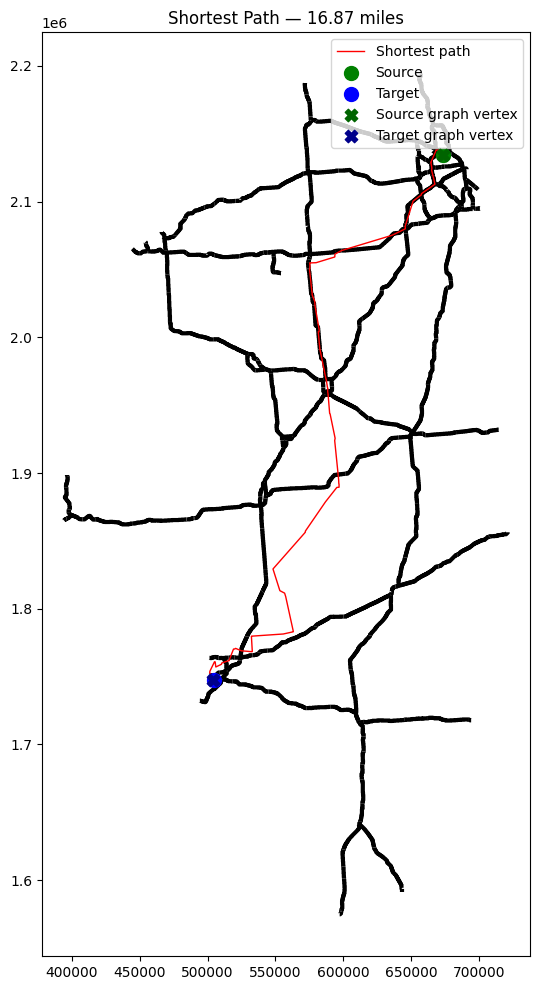

In [339]:
 # Find closest graph node to source

weight = "travel_time_hours"


source_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'DUNNING')
)].iloc[0]


target_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'East St. Louis')
)].iloc[0]

source_node = get_closest_vertex(source_point.geometry.representative_point(), G)
target_node = get_closest_vertex(target_point.geometry.representative_point(), G)

# Run shortest path using edge mileage
route_nodes = nx.shortest_path(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
)

route_miles = nx.shortest_path_length(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
    )


import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Convert the ordered route nodes into a line
route_line = LineString(route_nodes)

# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# Plot all atomic roads
AtomicRoads[
    (AtomicRoads['origin'] == 'I')
].plot(
    ax=ax,
    color="black",
    linewidth=3,
)

# Plot the shortest path
ax.plot(
    *route_line.xy,
    color="red",
    linewidth=1,
    label="Shortest path",
)

# Plot the original source and target representative points
ax.scatter(
    source_point.geometry.representative_point().x,
    source_point.geometry.representative_point().y,
    color="green",
    s=100,
    marker="o",
    label="Source",
    zorder=5,
)

ax.scatter(
    target_point.geometry.representative_point().x,
    target_point.geometry.representative_point().y,
    color="blue",
    s=100,
    marker="o",
    label="Target",
    zorder=5,
)

# Plot the graph vertices used for routing
ax.scatter(
    source_node[0],
    source_node[1],
    color="darkgreen",
    s=80,
    marker="X",
    label="Source graph vertex",
    zorder=6,
)

ax.scatter(
    target_node[0],
    target_node[1],
    color="darkblue",
    s=80,
    marker="X",
    label="Target graph vertex",
    zorder=6,
)

ax.legend()

ax.set_title(
    f"Shortest Path — {route_miles:.2f} miles"
)

plt.show()